In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import csv
from collections import OrderedDict

from pathlib import Path


In [2]:
NOTEBOOK_DIR: Path = Path.cwd()
PROJECT_ROOT: Path = NOTEBOOK_DIR.parent
CONFIG_PATH: Path = PROJECT_ROOT / "config" / "alignment.yml"

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

COMPLETE_SPECIFICATION = PROJECT_ROOT / (config["paths"]["input_metadata"])
PARTIAL_SPECIFICATION = PROJECT_ROOT / (config["paths"]["partial_metadata"])
FINAL_ACCESSIONS = PROJECT_ROOT / (config["paths"]["accession_tsv"])



In [ ]:
accessions = set()

df_acc = pd.read_csv(FINAL_ACCESSIONS)

for index, row in df_acc.iterrows():
    # print(row)
    # print()
    accessions.add(row['accession'])

# print(accessions)


In [17]:
genotype_dict = {}
p_type_dict = {}

df = pd.read_csv(COMPLETE_SPECIFICATION)

for index, row in df.iterrows():
    if row['accession'] in accessions:
        
        if row["p_type"] in p_type_dict:
            p_type_dict[str(row["p_type"])] += 1
        else:
            p_type_dict[str(row["p_type"])] = 1
       
        if row["genotype"] in genotype_dict:
            genotype_dict[str(row["genotype"])] += 1
        else:
            genotype_dict[str(row["genotype"])] = 1


print(f'genotypes: {genotype_dict}')
print()
print(f'p-types: {p_type_dict}')


genotypes: {'GII.17': 25, 'GII.4': 71, 'GII.2': 16, 'GII.16': 4, 'GII.5': 5, 'GII.3': 41, 'GII.12': 4, 'GII.13': 4, 'GII.26': 7, 'GII.1': 32, 'GII.NA2': 2, 'GII.6': 38, 'GII.7': 17, 'nan': 1, 'GII.14': 18, 'GII.8': 14, 'GII.10': 4, 'GII.24': 1, 'GII.23': 1, 'GII.9': 1}

p-types: {'GII.P17': 20, 'GII.P16': 61, 'GII.P31': 32, 'GII.PNA7': 1, 'GII.P38': 1, 'GII.P26': 7, 'GII.P4': 16, 'GII.PNA2': 2, 'GII.P33': 7, 'GII.P7': 61, 'GII.P21': 23, 'GII.P2': 5, 'nan': 1, 'Could': 14, 'GII.P12': 10, 'GII.P8': 14, 'GII.P1': 23, 'GII.P40': 4, 'GII.P24': 1, 'GII.P23': 1, 'GII.P6': 1, 'GII.P25': 1}


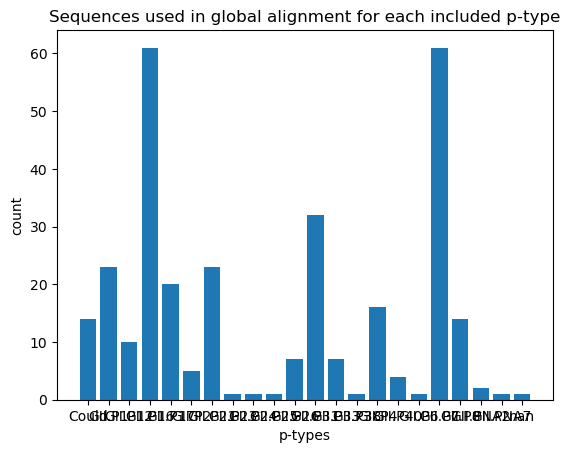

In [32]:
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))

# print(genotypes)


plt.bar(list(p_types.keys()), list(p_types.values()))
plt.xlabel('p-types')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included p-type')
plt.show()



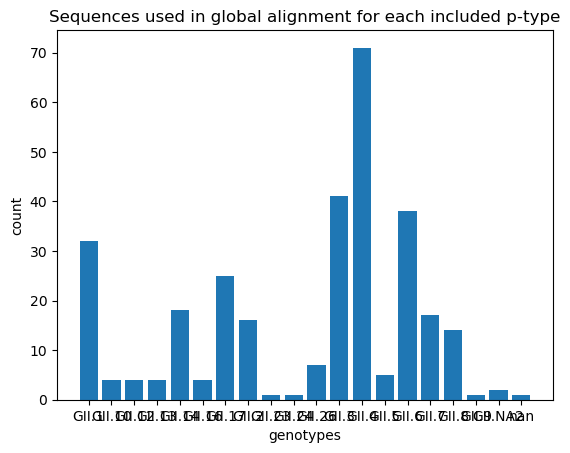

In [27]:
genotypes = OrderedDict(sorted(genotype_dict.items(), key = lambda item:item[0]))
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))

# print(genotypes)

plt.bar(list(genotypes.keys()), list(genotypes.values()))
plt.xlabel('genotypes')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included p-type')
plt.show()
